# Generative Modelling

**Goal**: Given some examples $x_i$, generate more examples similar to them.
**Approach**: Assume samples are coming from a parametrized data distribution $p_{\theta}(x)$. Set up the distribution, so that given parameters, there is an ideally efficient way to sample from it.
Optimize parameters with respect to some criterion (fit a model on the data points).
Bonus points if your distribution is tractable, i.e. if given a sample it is easy to calculate $p(x)$.

No labels needed in principle (in contrast to ***discriminative modelling***, where you go for modeling $p(y|x)$ given some labels $y$), unless you want to influence your sampled by conditioning on some variable.


# Mixture of Gaussians as a Generative Model


A Mixture of Gaussians (MoG) is one of the simplest generative models. It assumes that data is generated by first selecting one of $K$ Gaussian components according to a categorical distribution, then sampling from that component.

The density is:

$$p(x) = \sum_{k=1}^{K} \pi_k \, \mathcal{N}(x \mid \mu_k, \sigma_k^2 I)$$

where $\pi_k$ are the mixture weights ($\sum_k \pi_k = 1$), and each component has a diagonal covariance. The parameters are:

- $\mu_k \in \mathbb{R}^D$ — mean of component $k$
- $\log \sigma^2_k \in \mathbb{R}^D$ — log variance of component $k$ (learned in log space for stability)
- $w_k \in \mathbb{R}$ — unnormalized logit, with $\pi_k = \text{softmax}(w)_k$

## Data
Instead of using mixture of Gaussians to model one-dimensional functions with a few peaks, or two-dimensional clouds of points, here it's applied to a collection of handwritten digit images. So we model 64-dimensional vectors as a sum of gaussians, with 64-dimensional means and diagonal covariance matrices (so pixels in each component are uncorrelated).

## Training
- The model training is simply gradient descent to maximize the probability of the data set (given model parameters).
- More precisely, minimize the sum of log probabilities of all image vectors. The MoG log-likelihood is (with k components), for a sample vector x
  $$\log p(x) = \log \sum_{k=1}^{K} \pi_k \cdot \mathcal{N}(x \mid \mu_k, \Sigma_k)$$,  with component probabilities $\pi_k$
- To sample a new 'digit': pick a component (hidden variable), and sample from the corresponding gaussian distribution.

## Reference

- This notebook is following the great example from this book:
[Tomczak, J. M. (2024). Deep Generative Modeling. Springer Cham](https://link.springer.com/book/10.1007/978-3-031-64087-2)
- And its [github code](https://github.com/jmtomczak/intro_dgm)


In [1]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.datasets import load_digits
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as tt
import pandas as pd

In [2]:
import jax
import jax.numpy as jnp
import flax.linen as nn
from jax import random
import optax
from flax.training.train_state import TrainState

# Data Set

The model is trained on the scikit-learn handwritten digits dataset (8×8 grayscale images, 64-dimensional). Pixel values are normalized to $[0, 1]$ and small Gaussian noise is added as dequantization — this prevents the model from collapsing component variances to zero to exploit the discrete nature of the raw pixel values.

Component means and log variances are initialized from the empirical mean and variance of the training data so that the initial mixture roughly matches the marginal data distribution.

Use pytorch data loader for training with jax, only updating data type via collate function



In [3]:

class Digits(Dataset):
    """
    Stores digit images in memory in array / tensor format with a train / test / val split.
    """
    def __init__(self, mode='train', transforms=None):
        digits = load_digits()
        ranges = {'train': (0, 1000),
                  'val': (1000, 1350),
                  'test': (1350, len(digits.data))}
        start, end = ranges[mode]
        self.data = digits.data[start:end].astype(np.float32)
        print(f"Data set with shape {self.data.shape} for mode: {mode}")
        self.transforms = transforms

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        if self.transforms:
            sample = self.transforms(sample)
        return sample

def np_collate(samples):
    if type(samples[0]) == np.ndarray:
        return np.stack(samples)
    samples = zip(*samples)
    return [np.stack(s) for s in samples]

In [5]:
# normalization
# add some noise as form of dequantization for discrete pixel values
PIXEL_MAX = float(load_digits().data.max())
NOISE_FRACTION = 1 / 8
transforms = tt.Lambda(
    lambda x: x / PIXEL_MAX + np.random.randn(*x.shape) * (NOISE_FRACTION / PIXEL_MAX)
)

In [6]:
train_data = Digits(mode='train', transforms=transforms)
val_data = Digits(mode='val', transforms=transforms)
test_data = Digits(mode='test', transforms=transforms)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, collate_fn=np_collate)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False, collate_fn=np_collate)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False, collate_fn=np_collate)

Data set with shape (1000, 64) for mode: train
Data set with shape (350, 64) for mode: val
Data set with shape (447, 64) for mode: test


In [7]:
# for model parameter initialization
X_train = np.array([train_data[i] for i in range(len(train_data))])
data_mean = float(X_train.mean())
data_var  = float(X_train.var())
print(data_mean, data_var)

0.3069561530994033 0.1417039902892605


# Model and Training

Parameters are learned by maximizing the log-likelihood of the training data, equivalent to minimizing the negative log-likelihood (NLL):

$$\mathcal{L} = -\frac{1}{N} \sum_{n=1}^{N} \log \sum_{k=1}^{K} \pi_k \, \mathcal{N}(x_n \mid \mu_k, \sigma_k^2 I)$$

The inner sum is computed via the log-sum-exp trick for numerical stability. Gradients are computed with `jax.value_and_grad` and parameters are updated with Adam via Optax.



In [8]:
class MoG(nn.Module):
    """
    Mixture of gaussian model
    Instead of fitting via expectation maximization, maximize log probability of data given model parameters
    via stochastic gradient descent
    """
    D: int # data dimension
    K: int # number of components
    data_mean: float # data mean, use to initialize learned component mean parameters
    data_var: float # data variances, use to initialize learned component variance parameters
    PI: float = np.pi

    def setup(self):
        """
        Initialize learnable parameters
        """
        # component weights will be mapped to probabilities via softmax
        self.w = self.param('w', nn.initializers.zeros, (1, self.K))

        def mu_init(rng, shape):
          return self.data_mean + jnp.sqrt(self.data_var) * jax.random.normal(rng, shape)
        def log_var_init(rng, shape):
          # initialize so exp(log_var) ≈ data variance
          return jnp.full(shape, jnp.log(self.data_var))
        self.mu      = self.param('mu',      mu_init,      (1, self.K, self.D))
        self.log_var = self.param('log_var', log_var_init, (1, self.K, self.D))

    def __call__(self, x):
        """
        Calculate negative log probability of data given model parameters and MoG model to use in the loss function
        """
        # calculate component log mixture probabilities, shape (1, K)
        log_pi = jnp.log(jax.nn.softmax(self.w, 1))
        # log p(x | component k) for each sample, shape (B, K)
        log_N = self.log_diag_normal(x, self.mu, self.log_var)
        # return NLL per sample: -log p(x), shape (B,).
        return -jax.nn.logsumexp(log_pi + log_N, 1)

    def log_diag_normal(self, x, mu, log_var):
        # per-dimension log-probabilities under each Gaussian, shape (B, K, D)
        log_p = -0.5 * jnp.log(2. * self.PI) - 0.5 * log_var - 0.5 * jnp.exp(-log_var) * (jnp.expand_dims(x, 1) - mu)**2.
        # sum over image data dimension D
        return jnp.sum(log_p, 2)

    def sample(self, key, batch_size=64):
        """
        Generate batch_size new samples from distribution
        """
        pi = jax.nn.softmax(self.w, 1).squeeze(0)  # (K,)
        key, r_key = jax.random.split(key)
        # pick component, one for each sample
        indices = jax.random.choice(r_key, self.K, shape=(batch_size,), p=pi)  # (batch_size,)

        mu_selected = self.mu[0, indices]          # (batch_size, D)
        lv_selected = self.log_var[0, indices]     # (batch_size, D)
        key, r_key = jax.random.split(key)
        # pick each sample from corresponding diagonal multivariate normal distribution
        eps = jax.random.normal(r_key, (batch_size, self.D))
        return mu_selected + jnp.exp(0.5 * lv_selected) * eps

D = 64   # input dimension
K = 25  # number of Gaussian components

key_s, key = random.split(random.key(0), 2)

x = random.uniform(key_s, (2, D))
model = MoG(D=D, K=K, data_mean=data_mean, data_var=data_var)

key_s, key = random.split(random.key(0), 2)

params = model.init(key_s, x)
y = model.apply(params, x)

print('initialized parameter shapes:\n', jax.tree_util.tree_map(jnp.shape, params))
print('output:\n', y)


initialized parameter shapes:
 {'params': {'log_var': (1, 25, 64), 'mu': (1, 25, 64), 'w': (1, 25)}}
output:
 [40.861496 35.3353  ]


In [9]:
lr = 0.001

tx = optax.adam(learning_rate=lr)
state = TrainState.create(params=params, apply_fn=model.apply, tx=tx)

In [10]:
def evaluate(params, loader):
    losses = []
    for x in loader:
        loss = model.apply(params, x)
        losses.append(loss.flatten())
    return jnp.mean(jnp.concatenate(losses).astype(float))

In [11]:
@jax.jit
def train_step(train_state, x):

    def loss_function(params, x):
        loss = train_state.apply_fn(params, x)
        return loss.mean()

    loss, grads = jax.value_and_grad(loss_function)(train_state.params, x)
    train_state = train_state.apply_gradients(grads=grads)
    return train_state, loss

In [13]:
# trainings loop
num_epochs = 400
data = []

for e in range(num_epochs):
    losses = []
    for X in train_loader:
        state, loss = train_step(state, X)
        losses.append(loss)
    train_loss = np.mean(losses)
    val_loss = evaluate(state.params, val_loader)
    if e % (num_epochs // 10) == 0:
        print(f'Epoch: {e}')
        print(f'Train loss: {train_loss:.3f} | Val loss: {val_loss:.3f}')
    data.append({'epoch':e,
                 'lr':lr,
                 'train_loss': train_loss,
                 'val_loss': val_loss})

Epoch: 0
Train loss: 43.958 | Val loss: 42.343
Epoch: 40
Train loss: -6.014 | Val loss: -3.995
Epoch: 80
Train loss: -18.857 | Val loss: -15.930
Epoch: 120
Train loss: -28.868 | Val loss: -25.781
Epoch: 160
Train loss: -37.732 | Val loss: -33.289
Epoch: 200
Train loss: -44.631 | Val loss: -38.267
Epoch: 240
Train loss: -48.615 | Val loss: -40.238
Epoch: 280
Train loss: -50.544 | Val loss: -41.064
Epoch: 320
Train loss: -52.054 | Val loss: -41.549
Epoch: 360
Train loss: -53.233 | Val loss: -42.161


# Test / Evaluation

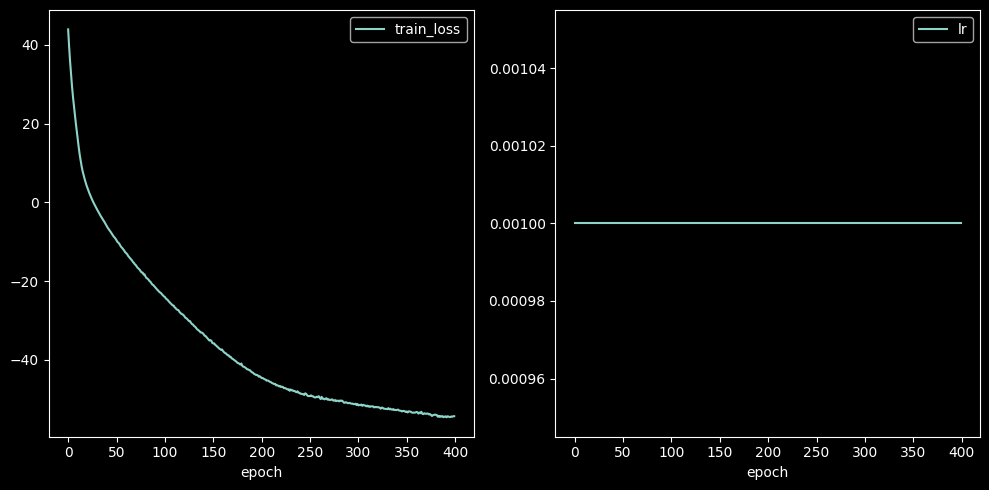

In [14]:
df = pd.DataFrame(data)

plt.figure(figsize=(10, 5))
ax = plt.subplot(1, 2, 1)
df.plot(x='epoch', y=['train_loss', 'val_loss'], ax=ax)
ax = plt.subplot(1, 2, 2)
df.plot(x='epoch', y=['lr'], ax=ax)
plt.tight_layout()


## Generation

To sample from the model:

1. Draw a component index $k \sim \text{Categorical}(\pi)$
2. Sample $x \sim \mathcal{N}(\mu_k, \sigma_k^2 I)$

With $K=25$ components for 10 digit classes, the model can capture within-class variation (e.g. different writing styles for the same digit).

In [25]:
def plot_real_samples(test_loader):
    num_x, num_y = 4, 4
    x = next(iter(test_loader))
    fig, ax = plt.subplots(num_x, num_y)
    for i, ax in enumerate(ax.flatten()):
        plottable_image = np.reshape(x[i], (8, 8))
        ax.imshow(plottable_image, cmap='gray')
        ax.axis('off')
    return

def plot_generated_samples(key):
    num_x, num_y = 4, 4
    key, key_s = random.split(key)
    x = model.apply(state.params, key_s, batch_size=num_x * num_y, method=model.sample)
    fig, ax = plt.subplots(num_x, num_y)
    for i, ax in enumerate(ax.flatten()):
        plottable_image = np.reshape(x[i], (8, 8))
        ax.imshow(plottable_image, cmap='gray')
        ax.axis('off')

def plot_means():
    w = state.params['params']['w']
    pi = jax.nn.softmax(w, 1).squeeze(0)  # (K,)
    num_x, num_y = 4, 4
    top_indices = jnp.argsort(pi)[::-1][:num_x * num_y]   # largest first
    mu = state.params['params']['mu'].squeeze(0)
    x  = np.array(mu[top_indices])

    fig, ax = plt.subplots(num_x, num_y)
    for i, ax in enumerate(ax.flatten()):
        plottable_image = np.reshape(x[i], (8, 8))
        ax.imshow(plottable_image, cmap='gray')
        ax.set_title(f'$\\pi$ = {pi[top_indices[i]].item():.5f}')
        ax.axis('off')
    fig.tight_layout()


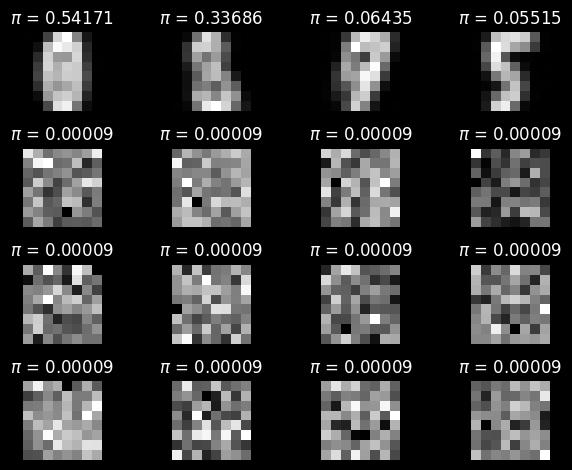

In [26]:
plot_means()

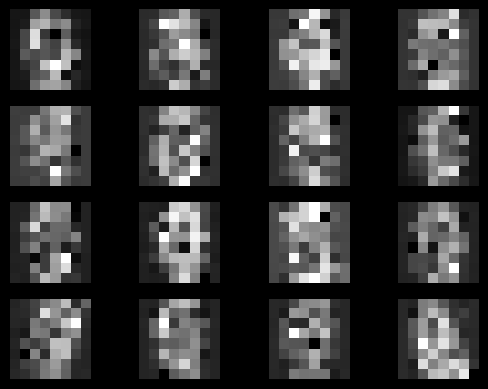

In [17]:
plot_generated_samples(key)

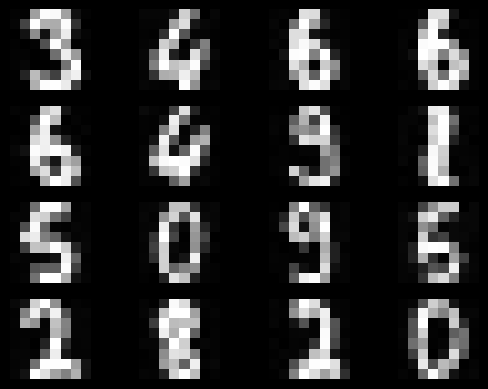

In [18]:
plot_real_samples(test_loader)